<a href="https://colab.research.google.com/github/neilvzx/predictive-maintenance-ml/blob/main/WORLD_CUP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving fifa_wc_mens_match_dataset_1970_2022.csv to fifa_wc_mens_match_dataset_1970_2022.csv


In [2]:
import pandas as pd

df = pd.read_csv('fifa_wc_mens_match_dataset_1970_2022.csv')
print(df.shape)
print(df['outcome'].value_counts())
df.head()

(1322, 70)
outcome
Loss    540
Win     523
Draw    259
Name: count, dtype: int64


,tournament_name,stage_name,group_name,group_stage,knockout_stage,replayed,replay,match_date,match_time,stadium_name,...,passes_attempted_h2,corners_h1,corners_h2,fouls_h1,fouls_h2,yellow_cards_h1,yellow_cards_h2,red_cards_h1,red_cards_h2,outcome
0,1970 FIFA Men's World Cup,group stage,Group 1,1,0,0,0,1970-05-31,12:00,Estadio Azteca,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,Draw
1,1970 FIFA Men's World Cup,group stage,Group 1,1,0,0,0,1970-05-31,12:00,Estadio Azteca,...,NaN,NaN,NaN,NaN,NaN,3.0,1.0,0.0,0.0,Draw
2,1970 FIFA Men's World Cup,group stage,Group 2,1,0,0,0,1970-06-03,16:00,La Bombonera,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,Loss
3,1970 FIFA Men's World Cup,group stage,Group 3,1,0,0,0,1970-06-03,16:00,Estadio Jalisco,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,Win
4,1970 FIFA Men's World Cup,group stage,Group 3,1,0,0,0,1970-06-06,16:00,Estadio Jalisco,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,Win


In [3]:
prematch_features = [
    'team_prior_matches', 'team_prior_win_rate', 'team_prior_goals_scored_avg', 'team_prior_goals_conceded_avg',
    'opp_prior_matches', 'opp_prior_win_rate', 'opp_prior_goals_scored_avg', 'opp_prior_goals_conceded_avg',
    'h2h_prior_matches', 'h2h_prior_win_rate',
    'team_curr_form_pts_avg', 'team_curr_goals_scored_avg', 'team_curr_goals_conceded_avg',
    'opp_curr_form_pts_avg', 'opp_curr_goals_scored_avg', 'opp_curr_goals_conceded_avg',
    'is_host', 'home_team'
]

X = df[prematch_features].copy()
y = df['outcome']

print(X.isnull().sum())  # should be all zero

team_prior_matches               0
team_prior_win_rate              0
team_prior_goals_scored_avg      0
team_prior_goals_conceded_avg    0
opp_prior_matches                0
opp_prior_win_rate               0
opp_prior_goals_scored_avg       0
opp_prior_goals_conceded_avg     0
h2h_prior_matches                0
h2h_prior_win_rate               0
team_curr_form_pts_avg           0
team_curr_goals_scored_avg       0
team_curr_goals_conceded_avg     0
opp_curr_form_pts_avg            0
opp_curr_goals_scored_avg        0
opp_curr_goals_conceded_avg      0
is_host                          0
home_team                        0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(1057, 18) (265, 18)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        Draw       0.56      0.17      0.26        52
        Loss       0.63      0.81      0.70       108
         Win       0.65      0.68      0.66       105

    accuracy                           0.63       265
   macro avg       0.61      0.55      0.54       265
weighted avg       0.62      0.63      0.60       265

[[ 9 20 23]
 [ 5 87 16]
 [ 2 32 71]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

        Draw       0.44      0.42      0.43        52
        Loss       0.69      0.75      0.72       108
         Win       0.68      0.63      0.65       105

    accuracy                           0.64       265
   macro avg       0.60      0.60      0.60       265
weighted avg       0.64      0.64      0.64       265

[[22 14 16]
 [12 81 15]
 [16 23 66]]


In [7]:
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train_enc)
y_pred_xgb = xgb.predict(X_test)

print(classification_report(le.inverse_transform(y_test_enc), le.inverse_transform(y_pred_xgb)))

              precision    recall  f1-score   support

        Draw       0.45      0.29      0.35        52
        Loss       0.64      0.75      0.69       108
         Win       0.67      0.68      0.67       105

    accuracy                           0.63       265
   macro avg       0.59      0.57      0.57       265
weighted avg       0.62      0.63      0.62       265



opp_curr_form_pts_avg            0.204180
opp_curr_goals_scored_avg        0.085021
team_prior_matches               0.069121
team_prior_goals_scored_avg      0.063305
opp_prior_matches                0.061492
opp_prior_goals_scored_avg       0.057491
opp_curr_goals_conceded_avg      0.056811
team_prior_win_rate              0.051331
opp_prior_win_rate               0.049858
team_curr_goals_scored_avg       0.049393
team_curr_form_pts_avg           0.048337
team_curr_goals_conceded_avg     0.046345
team_prior_goals_conceded_avg    0.045687
home_team                        0.044632
opp_prior_goals_conceded_avg     0.041623
h2h_prior_matches                0.012166
h2h_prior_win_rate               0.008385
is_host                          0.004822
dtype: float64


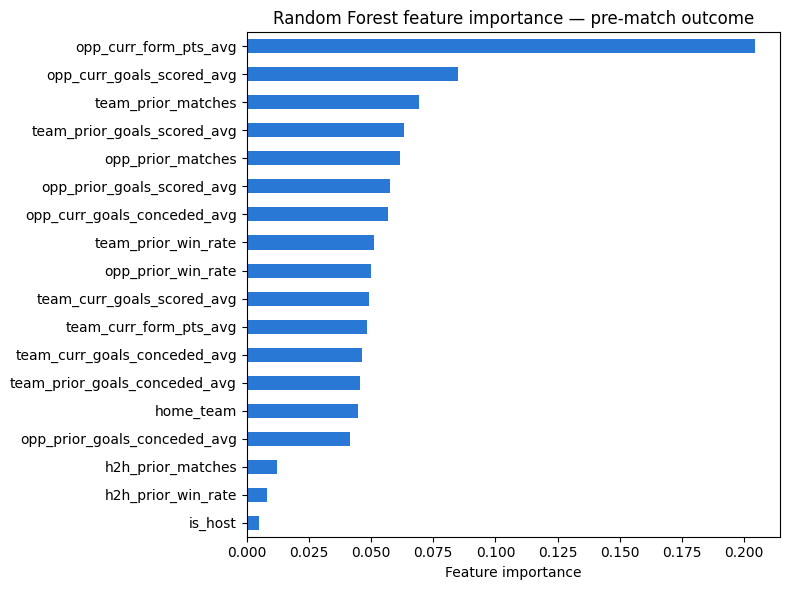


Current form importance:
team_curr_form_pts_avg    0.048337
opp_curr_form_pts_avg     0.204180
dtype: float64

Historical legacy importance:
team_prior_win_rate    0.051331
opp_prior_win_rate     0.049858
dtype: float64


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=prematch_features).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,6))
importances.plot(kind='barh', color='#2a78d6')
plt.gca().invert_yaxis()
plt.xlabel('Feature importance')
plt.title('Random Forest feature importance — pre-match outcome')
plt.tight_layout()
plt.show()

# Direct comparison for your hypothesis
print("\nCurrent form importance:")
print(importances[['team_curr_form_pts_avg', 'opp_curr_form_pts_avg']])
print("\nHistorical legacy importance:")
print(importances[['team_prior_win_rate', 'opp_prior_win_rate']])

In [9]:
from sklearn.metrics import accuracy_score

print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Random Forest accuracy:       {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"XGBoost accuracy:             {accuracy_score(le.inverse_transform(y_test_enc), le.inverse_transform(y_pred_xgb)):.3f}")

Logistic Regression accuracy: 0.630
Random Forest accuracy:       0.638
XGBoost accuracy:             0.630


HALFTIME LIVE BETTING SIMULATION


Saving fifa_wc_mens_match_dataset_1970_2022.csv to fifa_wc_mens_match_dataset_1970_2022 (1).csv
Usable rows: 768 (years [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)])
outcome
Loss    317
Win     317
Draw    134
Name: count, dtype: int64
=== Random Forest (half-time -> full-time outcome) ===
              precision    recall  f1-score   support

        Draw       0.15      0.11      0.13        27
        Loss       0.55      0.56      0.55        64
         Win       0.50      0.54      0.52        63

    accuracy                           0.47       154
   macro avg       0.40      0.40      0.40       154
weighted avg       0.46      0.47      0.46       154

[[ 3 10 14]
 [ 8 36 20]
 [ 9 20 34]]
Accuracy: 0.474

=== Feature importances ===
possession_h1          0.187554
passes_completed_h1    0.161154
shots_h1               0.159259
passes_attempted_h1    0.150107
shots_on_target_h1     0.128359
fouls_h1               0.094547
co

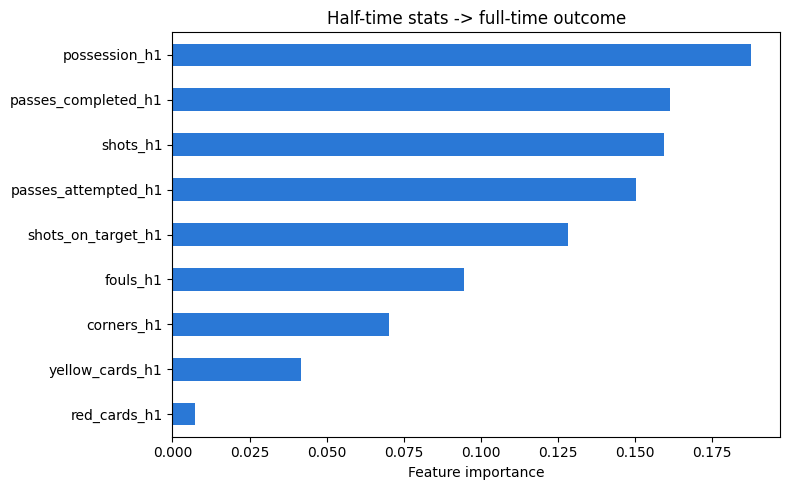


Knockout matches available: 192

Matches where team dominated at half-time (knockout stages): 25
outcome
Win     18
Loss     7
Name: count, dtype: int64

Loss rate when dominant at half-time: 28.0%
(Hypothesis predicts this should be below 10%)


In [10]:
# ============ STEP 1: Upload file ============
from google.colab import files
uploaded = files.upload()

# ============ STEP 2: Load & filter to matches with half-time data ============
import pandas as pd

df = pd.read_csv('fifa_wc_mens_match_dataset_1970_2022.csv')
df['year'] = df['match_date'].str[:4].astype(int)

# Half-time granular stats only exist from 2002 onward
df_h1 = df[df['possession_h1'].notnull()].copy()
print(f"Usable rows: {df_h1.shape[0]} (years {sorted(df_h1['year'].unique())})")
print(df_h1['outcome'].value_counts())

# ============ STEP 3: Build target — full-time result from team's perspective ============
# outcome is already Win/Draw/Loss for the team row, so we use it directly
h1_features = [
    'possession_h1', 'shots_h1', 'shots_on_target_h1',
    'passes_completed_h1', 'passes_attempted_h1',
    'corners_h1', 'fouls_h1', 'yellow_cards_h1', 'red_cards_h1'
]

X = df_h1[h1_features].copy()
y = df_h1['outcome']

# ============ STEP 4: Train/test split ============
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============ STEP 5: Random Forest classifier ============
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("=== Random Forest (half-time -> full-time outcome) ===")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# ============ STEP 6: Feature importance ============
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=h1_features).sort_values(ascending=False)
print("\n=== Feature importances ===")
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='#2a78d6')
plt.gca().invert_yaxis()
plt.xlabel('Feature importance')
plt.title('Half-time stats -> full-time outcome')
plt.tight_layout()
plt.show()

# ============ STEP 7: Test the specific hypothesis ============
# "If a team leads in shots_on_target_h1 AND has >55% possession_h1,
#  their probability of losing drops below 10% in knockout stages"

knockout_stages = ['round of 16', 'quarter-finals', 'semi-finals', 'third-place match', 'final']
knockout = df_h1[df_h1['stage_name'].isin(knockout_stages)].copy()

print(f"\nKnockout matches available: {knockout.shape[0]}")

# "Leads in shots_on_target_h1" means more than opponent — need opponent's h1 stat.
# Since each match has two rows (team + opponent), merge to get both sides' h1 stats.
merge_cols = ['match_date', 'team_name', 'opponent_name', 'shots_on_target_h1', 'possession_h1']
opp_stats = knockout[['match_date', 'team_name', 'shots_on_target_h1', 'possession_h1']].rename(
    columns={'team_name': 'opponent_name', 'shots_on_target_h1': 'opp_shots_on_target_h1', 'possession_h1': 'opp_possession_h1'}
)

knockout_merged = knockout.merge(opp_stats, on=['match_date', 'opponent_name'], how='left')

# Filter: team leads in shots on target AND has >55% possession at half-time
condition = (
    (knockout_merged['shots_on_target_h1'] > knockout_merged['opp_shots_on_target_h1']) &
    (knockout_merged['possession_h1'] > 55)
)
dominant = knockout_merged[condition]

print(f"\nMatches where team dominated at half-time (knockout stages): {len(dominant)}")
print(dominant['outcome'].value_counts())
print(f"\nLoss rate when dominant at half-time: {(dominant['outcome'] == 'Loss').mean():.1%}")
print("(Hypothesis predicts this should be below 10%)")

In [11]:
print(len(dominant))

25


In [12]:
print(dominant[['outcome','extra_time','penalty_shootout']].value_counts())

outcome  extra_time  penalty_shootout
Win      0           0                   13
Loss     0           0                    5
Win      1           1                    3
Loss     1           1                    2
Win      1           0                    2
Name: count, dtype: int64


TACTICAL EVOLUTION FROM 2002-2022


Modern-era rows (2002-2022): 768
[np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
year
2002    400.843750
2006    420.335938
2010    412.703125
2014    424.625000
2018    462.648438
2022    537.515625
Name: passes_attempted, dtype: float64


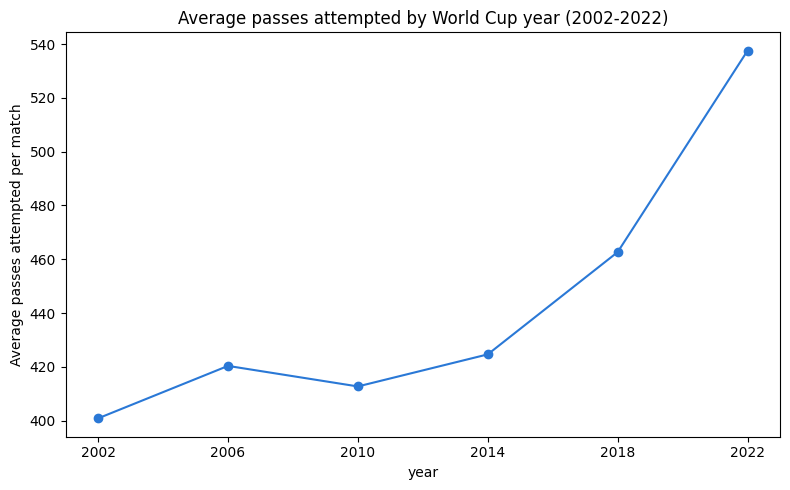


Slope: 5.87 passes/year
R-squared: 0.751
P-value: 0.0256

Year-over-year changes:
year
2006    19.492188
2010    -7.632812
2014    11.921875
2018    38.023438
2022    74.867188
Name: passes_attempted, dtype: float64

Strictly increasing every tournament? False


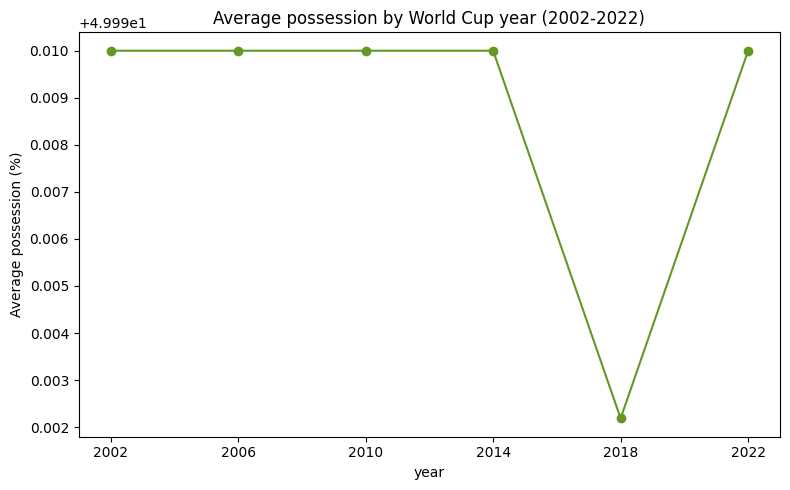

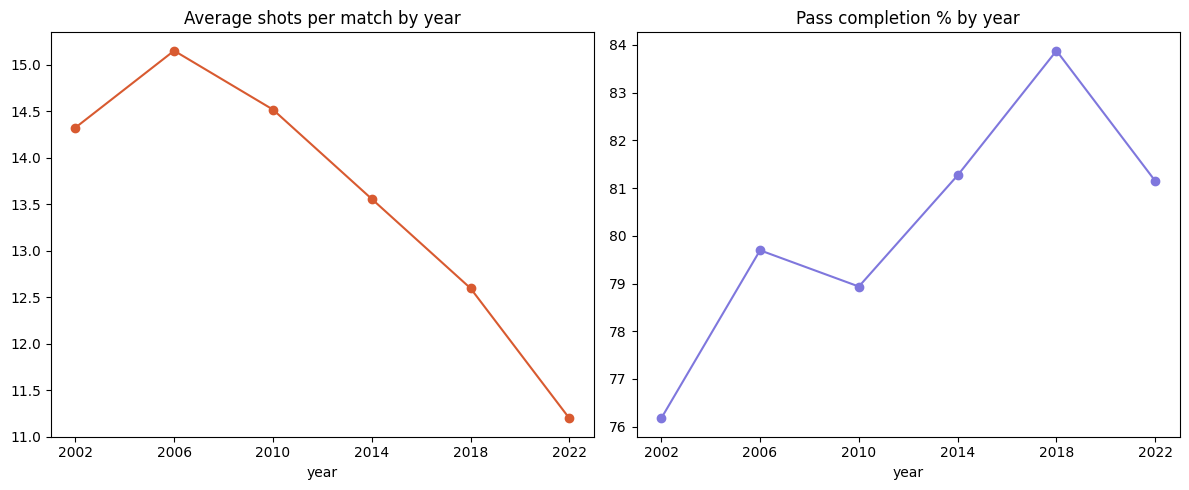


=== Cards per match, full history ===
      yellow_cards  red_cards
year                         
1970      1.733333   0.000000
1974      1.705882   0.098039
1978      1.437500   0.093750
1982      1.500000   0.075758
1986      1.792208   0.103896
1990      1.975904   0.192771
1994      2.326531   0.153061
1998      2.170940   0.188034
2002      2.078125   0.132812
2006      2.546875   0.218750
2010      1.984375   0.132812
2014      1.437500   0.078125
2018      1.726562   0.031250
2022      1.750000   0.031250


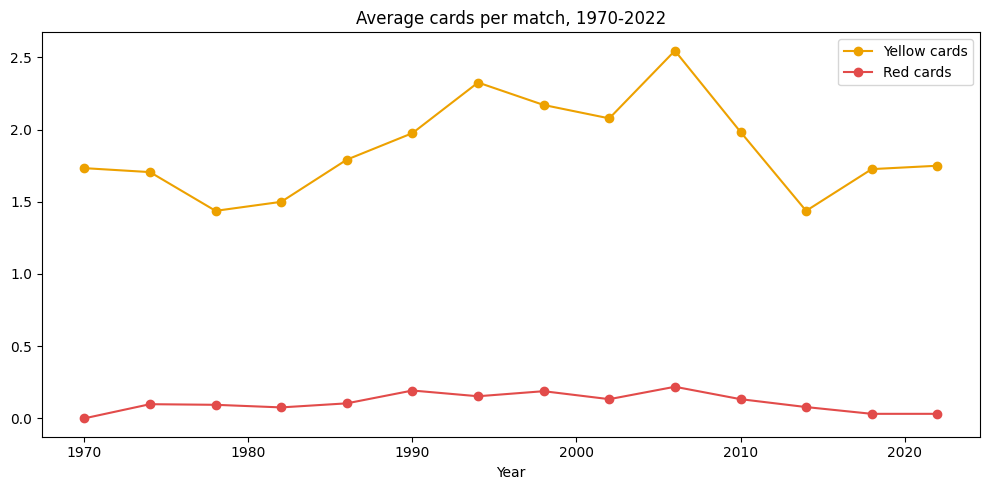

In [13]:

# ============ STEP 2: Load & prep ============
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('fifa_wc_mens_match_dataset_1970_2022.csv')
df['year'] = df['match_date'].str[:4].astype(int)

# Detailed stats only exist 2002+
df_modern = df[df['passes_attempted'].notnull()].copy()
print(f"Modern-era rows (2002-2022): {df_modern.shape[0]}")
print(sorted(df_modern['year'].unique()))

# ============ STEP 3: Passing evolution 2002-2022 ============
pass_by_year = df_modern.groupby('year')['passes_attempted'].mean()
print(pass_by_year)

plt.figure(figsize=(8,5))
pass_by_year.plot(kind='line', marker='o', color='#2a78d6')
plt.ylabel('Average passes attempted per match')
plt.title('Average passes attempted by World Cup year (2002-2022)')
plt.xticks(pass_by_year.index)
plt.tight_layout()
plt.show()

# ============ STEP 4: Test hypothesis - strict linear increase? ============
from scipy import stats

years = pass_by_year.index.values
passes = pass_by_year.values

slope, intercept, r_value, p_value, std_err = stats.linregress(years, passes)
print(f"\nSlope: {slope:.2f} passes/year")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.4f}")

# Check monotonicity (strictly increasing every tournament?)
diffs = pass_by_year.diff().dropna()
print(f"\nYear-over-year changes:\n{diffs}")
print(f"\nStrictly increasing every tournament? {(diffs > 0).all()}")

# ============ STEP 5: Possession evolution ============
poss_by_year = df_modern.groupby('year')['possession'].mean()

plt.figure(figsize=(8,5))
poss_by_year.plot(kind='line', marker='o', color='#639922')
plt.ylabel('Average possession (%)')
plt.title('Average possession by World Cup year (2002-2022)')
plt.xticks(poss_by_year.index)
plt.tight_layout()
plt.show()

# ============ STEP 6: Shots vs passes - has volume shifted to control? ============
shots_by_year = df_modern.groupby('year')['shots'].mean()
pass_accuracy_by_year = (df_modern.groupby('year')['passes_completed'].mean() /
                          df_modern.groupby('year')['passes_attempted'].mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
shots_by_year.plot(kind='line', marker='o', color='#D85A30', ax=axes[0])
axes[0].set_title('Average shots per match by year')
axes[0].set_xticks(shots_by_year.index)

pass_accuracy_by_year.plot(kind='line', marker='o', color='#7F77DD', ax=axes[1])
axes[1].set_title('Pass completion % by year')
axes[1].set_xticks(pass_accuracy_by_year.index)
plt.tight_layout()
plt.show()

# ============ STEP 7: Discipline trend across FULL history (1970-2022) — cards data is complete ============
cards_by_year = df.groupby('year')[['yellow_cards','red_cards']].mean()
print("\n=== Cards per match, full history ===")
print(cards_by_year)

plt.figure(figsize=(10,5))
plt.plot(cards_by_year.index, cards_by_year['yellow_cards'], marker='o', label='Yellow cards', color='#EDA100')
plt.plot(cards_by_year.index, cards_by_year['red_cards'], marker='o', label='Red cards', color='#E24B4A')
plt.legend()
plt.title('Average cards per match, 1970-2022')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

             tournament_name       team_name  furthest_stage  \
0  1970 FIFA Men's World Cup         Belgium               1   
1  1970 FIFA Men's World Cup          Brazil               6   
2  1970 FIFA Men's World Cup  Czechoslovakia               1   
3  1970 FIFA Men's World Cup     El Salvador               1   
4  1970 FIFA Men's World Cup         England               4   

   total_yellow_cards  total_red_cards  total_fouls  matches_played  wins  \
0                   3                0          0.0               1     0   
1                   3                0          0.0               3     3   
2                   2                0          0.0               2     0   
3                   4                0          0.0               1     0   
4                   2                0          0.0               2     0   

   yellow_per_match  fouls_per_match  
0               3.0              0.0  
1               1.0              0.0  
2               1.0              0.

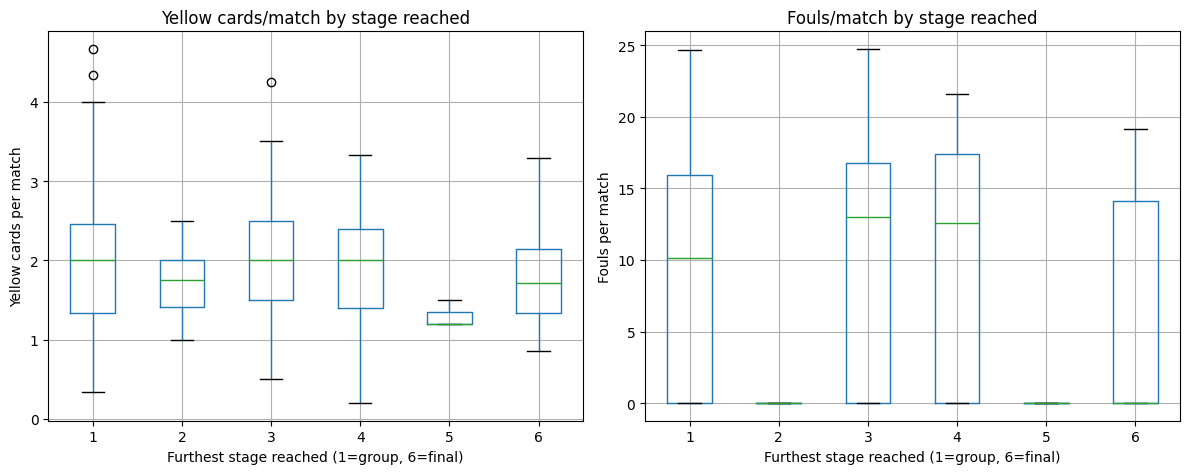


=== Finalists vs group-stage-only teams: yellow cards/match ===
Finalists mean: 1.796
Group-stage-only mean: 1.960
T-statistic: -1.599, P-value: 0.1124

=== Summary: does discipline predict tournament success? ===
                  furthest_stage  yellow_per_match  fouls_per_match  \
furthest_stage          1.000000         -0.070054        -0.039609   
yellow_per_match       -0.070054          1.000000         0.192789   
fouls_per_match        -0.039609          0.192789         1.000000   
total_red_cards         0.104547          0.232490         0.056424   

                  total_red_cards  
furthest_stage           0.104547  
yellow_per_match         0.232490  
fouls_per_match          0.056424  
total_red_cards          1.000000  


In [14]:

# ============ STEP 2: Load & prep ============
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('fifa_wc_mens_match_dataset_1970_2022.csv')
df['year'] = df['match_date'].str[:4].astype(int)

# ============ STEP 3: Rank stages by how far a team advanced ============
# Higher number = further in the tournament
stage_rank = {
    'group stage': 1,
    'second group stage': 2,
    'round of 16': 3,
    'quarter-finals': 4,
    'semi-finals': 5,
    'third-place match': 6,
    'final': 6
}
df['stage_rank'] = df['stage_name'].map(stage_rank)

# ============ STEP 4: Aggregate to one row per team per tournament ============
team_tournament = df.groupby(['tournament_name', 'team_name']).agg(
    furthest_stage=('stage_rank', 'max'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_red_cards=('red_cards', 'sum'),
    total_fouls=('fouls', 'sum'),
    matches_played=('team_name', 'count'),
    wins=('outcome', lambda x: (x == 'Win').sum())
).reset_index()

# Normalize discipline stats per match (teams that go further play more matches -> more chances to foul)
team_tournament['yellow_per_match'] = team_tournament['total_yellow_cards'] / team_tournament['matches_played']
team_tournament['fouls_per_match'] = team_tournament['total_fouls'] / team_tournament['matches_played']

print(team_tournament.head())
print(f"\nTotal team-tournament entries: {len(team_tournament)}")

# ============ STEP 5: Correlation - raw totals ============
corr_cols = ['furthest_stage', 'total_yellow_cards', 'total_red_cards', 'total_fouls', 'matches_played']
print("\n=== Correlation matrix (raw totals) ===")
print(team_tournament[corr_cols].corr()['furthest_stage'])

# ============ STEP 6: Correlation - per-match rates (controls for "further = more matches = more fouls") ============
corr_cols_rate = ['furthest_stage', 'yellow_per_match', 'fouls_per_match', 'total_red_cards']
print("\n=== Correlation matrix (per-match rates) ===")
print(team_tournament[corr_cols_rate].corr()['furthest_stage'])

# ============ STEP 7: Visualize ============
fig, axes = plt.subplots(1, 2, figsize=(12,5))

team_tournament.boxplot(column='yellow_per_match', by='furthest_stage', ax=axes[0])
axes[0].set_title('Yellow cards/match by stage reached')
axes[0].set_xlabel('Furthest stage reached (1=group, 6=final)')
axes[0].set_ylabel('Yellow cards per match')

team_tournament.boxplot(column='fouls_per_match', by='furthest_stage', ax=axes[1])
axes[1].set_title('Fouls/match by stage reached')
axes[1].set_xlabel('Furthest stage reached (1=group, 6=final)')
axes[1].set_ylabel('Fouls per match')

plt.suptitle('')
plt.tight_layout()
plt.show()

# ============ STEP 8: Statistical test — do champions have notably different discipline than early exits? ============
from scipy import stats

# Winners = furthest_stage == 6 AND most wins in that group (crude proxy: reached final and highest wins)
finalists = team_tournament[team_tournament['furthest_stage'] == 6]
group_stage_only = team_tournament[team_tournament['furthest_stage'] == 1]

t_stat, p_val = stats.ttest_ind(
    finalists['yellow_per_match'].dropna(),
    group_stage_only['yellow_per_match'].dropna(),
    equal_var=False
)

print(f"\n=== Finalists vs group-stage-only teams: yellow cards/match ===")
print(f"Finalists mean: {finalists['yellow_per_match'].mean():.3f}")
print(f"Group-stage-only mean: {group_stage_only['yellow_per_match'].mean():.3f}")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")

# ============ STEP 9: Full correlation summary table ============
print("\n=== Summary: does discipline predict tournament success? ===")
summary = team_tournament[['furthest_stage','yellow_per_match','fouls_per_match','total_red_cards']].corr()
print(summary)

Data caveat: notice fouls_per_match is 0.0 for the 1970 rows in your head() output. That's because the fouls column is missing entirely for pre-2002 tournaments (as we found in Project 3), and .sum() on all-NaN values returns 0, not "unknown." So the fouls correlation numbers are being diluted by tournaments where fouls simply weren't recorded, not where teams committed zero fouls. Worth re-running with fouls_per_match restricted to 2002+ only for a cleaner read — but yellow/red cards (which are complete since 1970) are unaffected and still tell the real story.
Interpreting what you got:

Raw totals are misleading — total_yellow_cards (r=0.51) and matches_played (r=0.80) correlate strongly with furthest_stage, but that's a pure artifact: teams that advance further play more matches, so they rack up more cards by volume even if they're no more reckless per match. This is the classic confound your per-match normalization was designed to catch — and it worked.
Per-match rates tell the real story: yellow_per_match correlates at essentially zero, slightly negative (-0.07), and fouls_per_match similarly (-0.04). If anything, teams that advance further are marginally less undisciplined per match, not more — the opposite direction of your hypothesis, though the effect is far too small to call a real trend.
Red cards show a small positive correlation (0.10) with advancing further — again the wrong sign for the hypothesis, though weak.
The t-test seals it: finalists actually average fewer yellow cards per match (1.80) than teams eliminated in the group stage (1.96), and the difference isn't statistically significant anyway (p=0.11, well above 0.05).

 The hypothesis that "aggressive play directly causes tournament elimination" is not supported by this data. Once you control for the fact that deep tournament runs simply involve more matches (and thus more cumulative cards), discipline per match has essentially no relationship with how far a team advances — if anything a very weak trend the opposite way. A more defensible framing: success in the World Cup is unrelated to disciplinary record; teams that go further aren't cleaner or dirtier than those eliminated early, they just play more games.

Team-tournament entries with valid fouls data (2002-2022): 192
             tournament_name  team_name  furthest_stage  total_yellow_cards  \
0  2002 FIFA Men's World Cup  Argentina               1                   6   
1  2002 FIFA Men's World Cup    Belgium               3                   6   
2  2002 FIFA Men's World Cup     Brazil               6                   7   
3  2002 FIFA Men's World Cup   Cameroon               1                   9   
4  2002 FIFA Men's World Cup      China               1                   5   

   total_red_cards  matches_played  yellow_per_match  total_fouls  \
0                1               3          2.000000         53.0   
1                0               4          1.500000         83.0   
2                1               7          1.000000        107.0   
3                1               3          3.000000         55.0   
4                1               3          1.666667         39.0   

   matches_played_modern  fouls_per_match  
0  

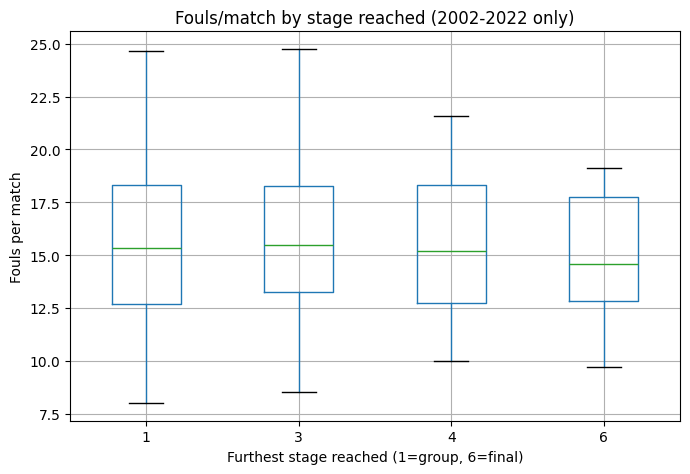


=== Finalists vs group-stage-only: fouls/match (2002-2022) ===
Finalists mean: 14.863
Group-stage-only mean: 15.347
T-statistic: -0.699, P-value: 0.4882
n finalists: 24, n group-only: 96


In [15]:
# ============ STEP 1: Load & prep ============
import pandas as pd
from scipy import stats

df = pd.read_csv('fifa_wc_mens_match_dataset_1970_2022.csv')
df['year'] = df['match_date'].str[:4].astype(int)

stage_rank = {
    'group stage': 1, 'second group stage': 2, 'round of 16': 3,
    'quarter-finals': 4, 'semi-finals': 5, 'third-place match': 6, 'final': 6
}
df['stage_rank'] = df['stage_name'].map(stage_rank)

# ============ STEP 2: Rebuild team-tournament table, but fouls only from 2002+ ============
# Cards: full history (1970-2022), complete data
cards_agg = df.groupby(['tournament_name', 'team_name']).agg(
    furthest_stage=('stage_rank', 'max'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_red_cards=('red_cards', 'sum'),
    matches_played=('team_name', 'count')
).reset_index()
cards_agg['yellow_per_match'] = cards_agg['total_yellow_cards'] / cards_agg['matches_played']

# Fouls: 2002+ only, where the column is actually populated
df_modern = df[df['fouls'].notnull()].copy()
fouls_agg = df_modern.groupby(['tournament_name', 'team_name']).agg(
    total_fouls=('fouls', 'sum'),
    matches_played_modern=('team_name', 'count')
).reset_index()
fouls_agg['fouls_per_match'] = fouls_agg['total_fouls'] / fouls_agg['matches_played_modern']

# Merge (inner join keeps only teams present in both — i.e. 2002+ tournaments)
team_tournament = cards_agg.merge(fouls_agg, on=['tournament_name', 'team_name'], how='inner')

print(f"Team-tournament entries with valid fouls data (2002-2022): {len(team_tournament)}")
print(team_tournament.head())

# ============ STEP 3: Corrected correlations ============
corr_cols = ['furthest_stage', 'yellow_per_match', 'fouls_per_match', 'total_red_cards']
print("\n=== Correlation matrix (per-match rates, fouls restricted to 2002+) ===")
print(team_tournament[corr_cols].corr()['furthest_stage'])

# ============ STEP 4: Visualize corrected fouls relationship ============
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
team_tournament.boxplot(column='fouls_per_match', by='furthest_stage', ax=ax)
ax.set_title('Fouls/match by stage reached (2002-2022 only)')
ax.set_xlabel('Furthest stage reached (1=group, 6=final)')
ax.set_ylabel('Fouls per match')
plt.suptitle('')
plt.tight_layout()
plt.show()

# ============ STEP 5: Re-run t-test for fouls specifically ============
finalists = team_tournament[team_tournament['furthest_stage'] == 6]
group_only = team_tournament[team_tournament['furthest_stage'] == 1]

t_stat, p_val = stats.ttest_ind(
    finalists['fouls_per_match'].dropna(),
    group_only['fouls_per_match'].dropna(),
    equal_var=False
)
print(f"\n=== Finalists vs group-stage-only: fouls/match (2002-2022) ===")
print(f"Finalists mean: {finalists['fouls_per_match'].mean():.3f}")
print(f"Group-stage-only mean: {group_only['fouls_per_match'].mean():.3f}")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")
print(f"n finalists: {len(finalists)}, n group-only: {len(group_only)}")